# 05 — Visualize Proximity Analysis
Loads cleaned proximity data from `04_clean_proximity.ipynb` and produces maps and charts.

In [1]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

def find_repo_root(start=Path().resolve()):
    for parent in [start] + list(start.parents):
        if (parent / 'README.md').exists() and (parent / 'data').exists():
            return parent
    raise FileNotFoundError('Could not find repo root.')

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
DATA_IN = REPO_ROOT / 'data' / 'cleaned_data'

print('Working directory:', os.getcwd())

Working directory: /Users/charlottewest/Documents/QSS20-CW-Final


## Load Cleaned Data

In [2]:
# GeoDataFrame for mapping
proximity_gdf = gpd.read_file(DATA_IN / 'proximity_final.geojson')

# Flat CSV for stats and charts
proximity_df = pd.read_csv(DATA_IN / 'proximity_final.csv', dtype={'PWSID': str})

# Individual facility locations with PWS assignments
facilities_df = pd.read_csv(DATA_IN / 'echo_facilities_with_pws.csv', dtype={'PWSID': str})
facilities_gdf = gpd.GeoDataFrame(
    facilities_df,
    geometry = gpd.points_from_xy(facilities_df['Longitude'], facilities_df['Latitude']),
    crs      = 'EPSG:4326'
)

# Convert numeric cols
for col in ['max_pfas', 'mean_pfas', 'pct_poc', 'pct_black', 'pct_hispanic',
            'hh_median_income', 'total_facilities']:
    proximity_df[col] = pd.to_numeric(proximity_df[col], errors='coerce')

print(f'Water systems: {len(proximity_df)}')
print(f'With PFAS data: {proximity_df["max_pfas"].notna().sum()}')
print(f'With facilities inside: {(proximity_df["total_facilities"] > 0).sum()}')
print(proximity_df.columns.tolist())

Water systems: 558
With PFAS data: 245
With facilities inside: 204
['PWSID', 'PWS_Name', 'Population_Served_Count', 'max_pfas', 'mean_pfas', 'total_detections', 'pws_name', 'exceeds_mcl_max', 'exceeds_mcl_mean', 'total_facilities', 'n_airports', 'n_airports_(part_139)', 'n_cement_mfg', 'n_chemical_mfg', 'n_cleaning_product_mfg', 'n_consumer_products', 'n_electronics_industry', 'n_fire_protection', 'n_fire_training', 'n_furniture_and_carpet', 'n_glass_products', 'n_industrial_gas', 'n_metal_coating', 'n_metal_machinery_mfg', 'n_mining_and_refining', 'n_national_defense', 'n_oil_and_gas', 'n_paints_and_coatings', 'n_paper_mills_and_products', 'n_petroleum', 'n_plastics_and_resins', 'n_printing', 'n_textiles_and_leather', 'n_waste_management', 'has_facility', 'pct_poc', 'pct_black', 'pct_hispanic', 'pct_nonhispanic_white', 'hh_median_income', 'total_pop']


## Map: PWS Service Areas Colored by PFAS Level with Facilities Overlaid

In [ ]:
fig, ax = plt.subplots(figsize=(12, 14))

# Service areas colored by mean PFAS
proximity_gdf.plot(
    column       = 'mean_pfas',
    cmap         = 'OrRd',
    linewidth    = 0.4,
    edgecolor    = 'grey',
    legend       = True,
    missing_kwds = {'color': 'lightgrey', 'label': 'No PFAS Data'},
    ax           = ax
)

# Rename industry labels for display
facilities_gdf['Industry'] = facilities_gdf['Industry'].replace(
    {'Chemical Mfg': 'Chemical Manufacturing'}
)

# Overlay ECHO facilities by industry type
colors = {
    'Chemical Manufacturing' : 'blue',
    'Airports'               : 'black',
    'National Defense'       : 'darkgreen',
    'Fire Training'          : 'purple',
    'Waste Management'       : 'brown',
}
for industry, color in colors.items():
    subset = facilities_gdf[facilities_gdf['Industry'] == industry]
    subset.plot(ax=ax, color=color, markersize=15, zorder=5, alpha=0.7, label=industry)

# All other industries
other = facilities_gdf[~facilities_gdf['Industry'].isin(colors.keys())]
other.plot(ax=ax, color='orange', markersize=8, zorder=4, alpha=0.4, label='Other Industry')

ax.legend(fontsize=10, loc='lower left')
ax.set_title('Mean PFAS Levels by Water System Service Area\nwith PFAS-Handling Facilities Overlaid — New Jersey',
             fontsize=14, fontweight='bold', pad=15)
ax.set_axis_off()

plt.tight_layout()
os.makedirs('output', exist_ok=True)
plt.savefig('output/pws_pfas_with_facilities.png', dpi=300, bbox_inches='tight')
plt.show()

## PFAS Levels: Water Systems With vs Without Facilities Inside

Mean PFAS — with facility:    0.00052 µg/L
Mean PFAS — without facility: 0.00027 µg/L
T-statistic: 3.007  |  P-value: 0.0029


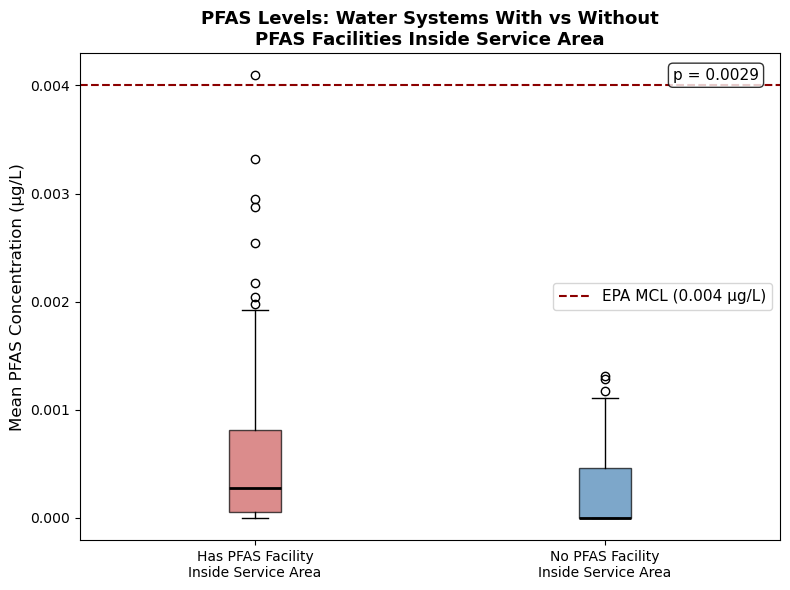

In [4]:
plot_df = proximity_df[['has_facility', 'mean_pfas', 'max_pfas']].dropna()

with_fac    = plot_df[plot_df['has_facility'] == True]['mean_pfas']
without_fac = plot_df[plot_df['has_facility'] == False]['mean_pfas']

t_stat, pvalue = stats.ttest_ind(with_fac, without_fac)
print(f'Mean PFAS — with facility:    {with_fac.mean():.5f} µg/L')
print(f'Mean PFAS — without facility: {without_fac.mean():.5f} µg/L')
print(f'T-statistic: {t_stat:.3f}  |  P-value: {pvalue:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(
    [with_fac, without_fac],
    tick_labels  = ['Has PFAS Facility\nInside Service Area',
                    'No PFAS Facility\nInside Service Area'],
    patch_artist = True,
    medianprops  = {'color': 'black', 'linewidth': 2}
)
bp['boxes'][0].set_facecolor('indianred');  bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('steelblue'); bp['boxes'][1].set_alpha(0.7)

ax.axhline(y=0.004, color='darkred', linestyle='--', linewidth=1.5, label='EPA MCL (0.004 µg/L)')
ax.set_ylabel('Mean PFAS Concentration (µg/L)', fontsize=12)
ax.set_title('PFAS Levels: Water Systems With vs Without\nPFAS Facilities Inside Service Area',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.text(0.97, 0.97, f'p = {pvalue:.4f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('output/pfas_with_vs_without_facility.png', dpi=300, bbox_inches='tight')
plt.show()

## Demographics: Water Systems With vs Without Facilities

In [5]:
demo_cols   = ['pct_poc', 'pct_black', 'pct_hispanic', 'hh_median_income']
demo_labels = ['% POC', '% Black', '% Hispanic', 'Median Income ($)']

with_fac_demo    = proximity_df[proximity_df['has_facility'] == True][demo_cols]
without_fac_demo = proximity_df[proximity_df['has_facility'] == False][demo_cols]

print(f"{'Metric':<22} {'With Facility':>15} {'Without Facility':>18} {'p-value':>10} {'Sig':>6}")
print('-' * 75)
for col, label in zip(demo_cols, demo_labels):
    w  = pd.to_numeric(with_fac_demo[col],    errors='coerce').dropna()
    wo = pd.to_numeric(without_fac_demo[col], errors='coerce').dropna()
    t, p = stats.ttest_ind(w, wo)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{label:<22} {w.mean():>15.1f} {wo.mean():>18.1f} {p:>10.4f} {sig:>6}')

Metric                   With Facility   Without Facility    p-value    Sig
---------------------------------------------------------------------------
% POC                             25.4               12.3     0.0000    ***
% Black                           11.5                5.8     0.0002    ***
% Hispanic                        17.3               10.0     0.0000    ***
Median Income ($)             116597.8           113803.4     0.5798       


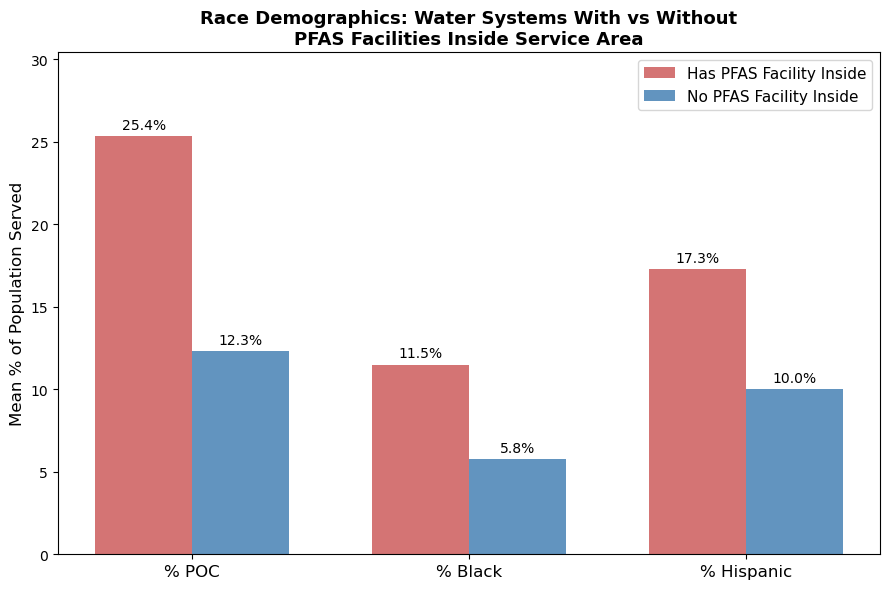

In [6]:
# Bar chart of race demographics
race_cols   = ['pct_poc', 'pct_black', 'pct_hispanic']
race_labels = ['% POC', '% Black', '% Hispanic']

with_means    = [pd.to_numeric(with_fac_demo[c],    errors='coerce').mean() for c in race_cols]
without_means = [pd.to_numeric(without_fac_demo[c], errors='coerce').mean() for c in race_cols]

x     = np.arange(len(race_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, with_means,    width, label='Has PFAS Facility Inside', color='indianred', alpha=0.85)
bars2 = ax.bar(x + width/2, without_means, width, label='No PFAS Facility Inside',  color='steelblue', alpha=0.85)

ax.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(race_labels, fontsize=12)
ax.set_ylabel('Mean % of Population Served', fontsize=12)
ax.set_title('Race Demographics: Water Systems With vs Without\nPFAS Facilities Inside Service Area',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(with_means + without_means) * 1.2)

plt.tight_layout()
plt.savefig('output/demographics_facility_vs_no_facility.png', dpi=300, bbox_inches='tight')
plt.show()

## PFAS vs Number of Facilities (Pearson Correlation)

Pearson r: 0.073
P-value:   0.2554


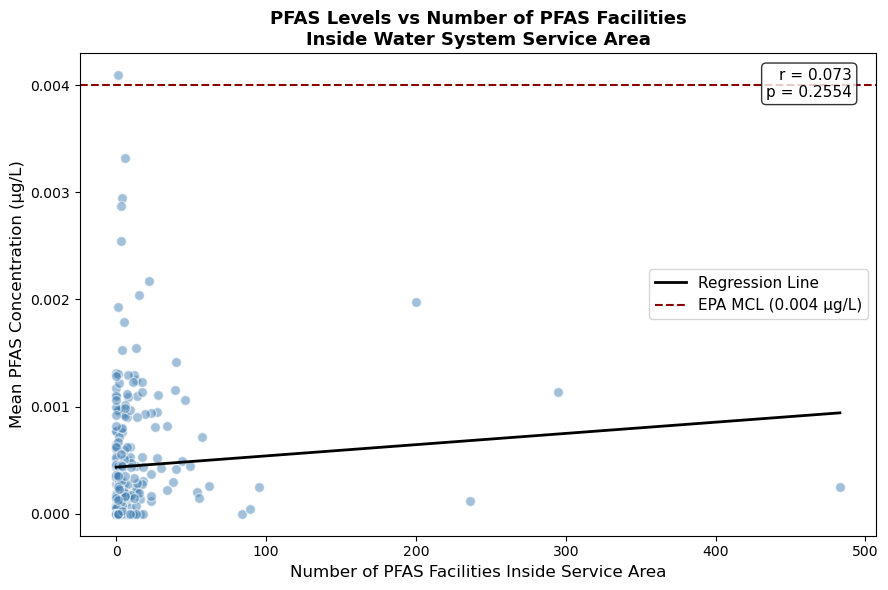

In [7]:
corr_df = proximity_df[['mean_pfas', 'total_facilities']].dropna()
corr_df['total_facilities'] = pd.to_numeric(corr_df['total_facilities'], errors='coerce')
corr_df = corr_df.dropna()

corr, pvalue = stats.pearsonr(corr_df['mean_pfas'], corr_df['total_facilities'])
print(f'Pearson r: {corr:.3f}')
print(f'P-value:   {pvalue:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(corr_df['total_facilities'], corr_df['mean_pfas'],
           color='steelblue', alpha=0.5, edgecolor='white', s=50)

m, b = np.polyfit(corr_df['total_facilities'], corr_df['mean_pfas'], 1)
x_line = np.linspace(corr_df['total_facilities'].min(), corr_df['total_facilities'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=2, label='Regression Line')

ax.axhline(y=0.004, color='darkred', linestyle='--', linewidth=1.5, label='EPA MCL (0.004 µg/L)')
ax.set_xlabel('Number of PFAS Facilities Inside Service Area', fontsize=12)
ax.set_ylabel('Mean PFAS Concentration (µg/L)', fontsize=12)
ax.set_title('PFAS Levels vs Number of PFAS Facilities\nInside Water System Service Area',
             fontsize=13, fontweight='bold')
ax.text(0.97, 0.97, f'r = {corr:.3f}\np = {pvalue:.4f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('output/pfas_vs_facility_count_scatter.png', dpi=300, bbox_inches='tight')
plt.show()